In [ ]:
# Research_Question_7:	How does media sentiment toward food price infaltion evolve between 2023 and 2024?

In [1]:
import pandas as pd
import json

In [2]:
df_inflation = pd.read_json("FredDatensatz.json")
df_inflation.head()

,realtime_start,realtime_end,observation_start,observation_end,units,output_type,file_type,order_by,sort_order,count,offset,limit,observations
0,2026-02-25,2026-02-25,1600-01-01,9999-12-31,lin,1,json,observation_date,asc,360,0,100000,"{'realtime_start': '2026-02-25', 'realtime_end..."
1,2026-02-25,2026-02-25,1600-01-01,9999-12-31,lin,1,json,observation_date,asc,360,0,100000,"{'realtime_start': '2026-02-25', 'realtime_end..."
2,2026-02-25,2026-02-25,1600-01-01,9999-12-31,lin,1,json,observation_date,asc,360,0,100000,"{'realtime_start': '2026-02-25', 'realtime_end..."
3,2026-02-25,2026-02-25,1600-01-01,9999-12-31,lin,1,json,observation_date,asc,360,0,100000,"{'realtime_start': '2026-02-25', 'realtime_end..."
4,2026-02-25,2026-02-25,1600-01-01,9999-12-31,lin,1,json,observation_date,asc,360,0,100000,"{'realtime_start': '2026-02-25', 'realtime_end..."


In [3]:
df_news = pd.read_json("gdelt_food_inflation_news.json")
df_news.head()

,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry
0,https://www.haberler.com/guncel/disk-ar-en-yok...,,Disk - Ar : En Yoksul Gelir Grubunun Gıda Enf...,20231204T121500Z,https://i.hbrcdn.com/haber/2023/12/04/disk-ar-...,haberler.com,Turkish,Turkey
1,https://t24.com.tr/haber/disk-ar-en-yoksul-gel...,https://t24.com.tr/amp/haber/disk-ar-en-yoksul...,DİSK - AR : En yoksul gelir grubunun gıda enfl...,20231204T120000Z,https://media-cdn.t24.com.tr/media/library/202...,t24.com.tr,Turkish,Turkey
2,https://www.gercekgundem.com/ekonomi/aci-gerce...,https://www.gercekgundem.com/amp/ekonomi/aci-g...,Acı gerçek DİSK - AR ın raporunda : En yoksul...,20231204T143000Z,https://img.gercekgundem.com/rcman/Cw1280h720q...,gercekgundem.com,Turkish,Turkey
3,https://www.haber3.com/ekonomi/dar-gelirlinin-...,https://www.haber3.com/amp/ekonomi/dar-gelirli...,Dar gelirlinin gıda enflasyonu belli oldu,20231204T113000Z,https://i.haber3.com/2/1280/720/storage/files/...,haber3.com,Turkish,Turkey
4,https://www.financialexpress.com/opinion/how-t...,https://www.financialexpress.com/opinion/how-t...,How to tackle food inflation,20231204T231500Z,https://www.financialexpress.com/wp-content/up...,financialexpress.com,English,India


In [4]:
from textblob import TextBlob

df_news["sentiment"] = df_news["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [7]:
print(df_news.columns)

Index(['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain',
       'language', 'sourcecountry', 'sentiment'],
      dtype='str')


In [8]:
df_news["seendate"] = pd.to_datetime(df_news["seendate"])
df_news["year"] = df_news["seendate"].dt.year

In [9]:
sentiment_by_year = df_news.groupby("year")["sentiment"].mean()
print(sentiment_by_year)

year
2023   -0.000023
2024    0.000000
Name: sentiment, dtype: float64


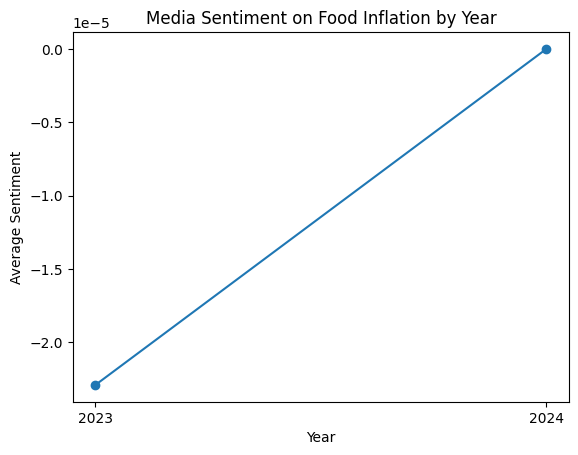

In [11]:
import matplotlib.pyplot as plt

sentiment_by_year.plot(marker="o")

plt.title("Media Sentiment on Food Inflation by Year")
plt.xlabel("Year")
plt.ylabel("Average Sentiment")

plt.xticks([2023, 2024])   # nur ganze Jahre anzeigen

plt.show()